## Step 1: Extract the Dataset

First, we need to extract the images from your zip file. Make sure your zip file (e.g., `dataset.zip`) is uploaded to your Colab environment, typically in the `/content/` directory or change the path below to its correct location.

In [8]:
import zipfile
import os

zip_file_path = '/content/archive (21).zip'
 # Make sure this path is correct
extract_path = '/content/extracted_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to: {extract_path}")

# Verify the contents (optional)
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


Dataset extracted to: /content/extracted_dataset
Contents of the extracted directory:
extracted_dataset/
    no/
        no 99.jpg
        29 no.jpg
        20 no.jpg
        N17.jpg
        39 no.jpg
        No15.jpg
        15 no.jpg
        8 no.jpg
        no 923.jpg
        no 4.jpg
        No16.jpg
        4 no.jpg
        6 no.jpg
        no 89.jpg
        N26.JPG
        49 no.jpg
        24 no.jpg
        31 no.jpg
        28 no.jpg
        No22.jpg
        33 no.jpg
        45 no.jpg
        no 92.jpg
        22 no.jpg
        41 no.jpg
        no 96.jpg
        no 3.jpg
        N16.jpg
        N22.JPG
        46 no.jpg
        no 9.png
        No13.jpg
        40 no.jpg
        42 no.jpg
        no 98.jpg
        18 no.jpg
        no 90.jpg
        10 no.jpg
        48 no.jpeg
        23 no.jpg
        19 no.jpg
        43 no.jpg
        14 no.jpg
        36 no.jpg
        No12.jpg
        30 no.jpg
        13 no.jpg
        34 no.jpg
        no 100.jpg
        no 97.jpg
   

## Step 2: Load and Preprocess Images

Now we'll load the images from the 'yes' and 'no' folders, resize them to a uniform size, and prepare them for feature extraction. We'll use a standard size like 128x128 pixels. We'll also assign labels: 1 for 'yes' (tumor) and 0 for 'no' (non-tumor).

In [9]:
import cv2
import numpy as np
import os
from tqdm import tqdm # For progress bar

# Define the base directory where the images are extracted
base_dir = '/content/extracted_dataset/brain_tumor_dataset'

# Define the categories (tumor and non-tumor)
categories = ['no', 'yes']
IMG_SIZE = 128 # We will resize all images to 128x128 pixels

data = []

for category in categories:
    path = os.path.join(base_dir, category)
    class_num = categories.index(category) # 0 for 'no', 1 for 'yes'
    print(f"Loading images from: {path}")
    for img_name in tqdm(os.listdir(path)):
        try:
            img_array = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
            # Resize the image
            new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            data.append([new_array, class_num])
        except Exception as e:
            print(f"Error loading image {img_name}: {e}")

print(f"Total images loaded: {len(data)}")

# Shuffle the data to ensure randomness for training/testing
import random
random.shuffle(data)

X = [] # Features (image data)
y = [] # Labels (tumor or not)

for features, label in data:
    X.append(features)
    y.append(label)

# Convert to numpy arrays and normalize pixel values
X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1) # Add a channel dimension for grayscale
X = X / 255.0 # Normalize to 0-1 range
y = np.array(y)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")


Loading images from: /content/extracted_dataset/brain_tumor_dataset/no


100%|██████████| 98/98 [00:00<00:00, 465.25it/s]


Loading images from: /content/extracted_dataset/brain_tumor_dataset/yes


100%|██████████| 155/155 [00:00<00:00, 702.01it/s]

Total images loaded: 253
Shape of features (X): (253, 128, 128, 1)
Shape of labels (y): (253,)


## Step 3: Feature Extraction (PCA) and Data Splitting

Since we are not using deep learning, raw pixel values as features can be very high-dimensional. We will flatten the images and then use Principal Component Analysis (PCA) to reduce the dimensionality and extract the most significant features. After that, we'll split the dataset into training and testing sets.

Shape of flattened features: (253, 16384)
Number of components after PCA (retaining 95% variance): 130
Shape of features after PCA: (253, 130)


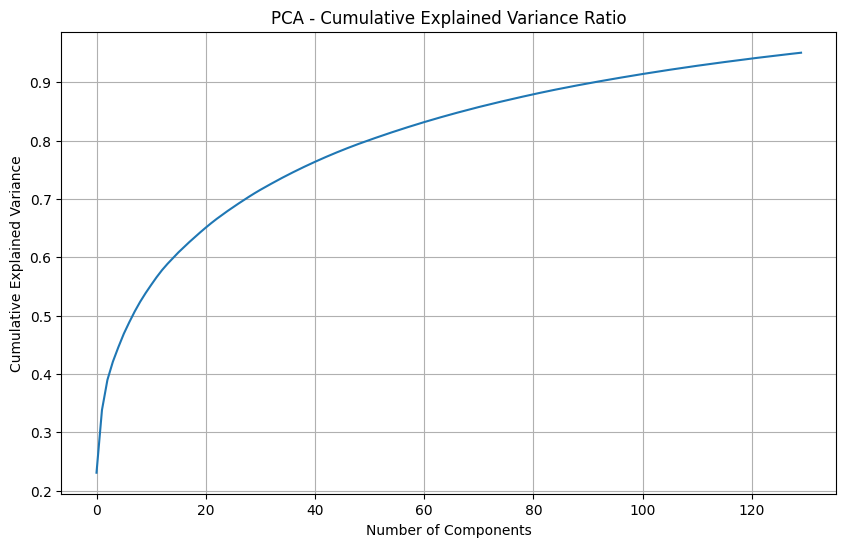

Shape of X_train: (202, 130)
Shape of X_test: (51, 130)
Shape of y_train: (202,)
Shape of y_test: (51,)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Flatten the images: (num_images, height, width, channels) -> (num_images, height * width * channels)
X_flattened = X.reshape(X.shape[0], -1)
print(f"Shape of flattened features: {X_flattened.shape}")

# Apply StandardScaler before PCA (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flattened)

# Apply PCA
# Let's start by retaining a high percentage of variance, say 95%
pca = PCA(n_components=0.95) # Retain 95% of variance
X_pca = pca.fit_transform(X_scaled)

print(f"Number of components after PCA (retaining 95% variance): {pca.n_components_}")
print(f"Shape of features after PCA: {X_pca.shape}")

# Optionally, plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


## Step 4: Train a Classification Model

We will now train a Logistic Regression classifier on our PCA-transformed training data. Logistic Regression is a good choice for binary classification and is widely used for its simplicity and interpretability.

Training Logistic Regression model...
Model training complete.

Model Evaluation:
Accuracy: 0.7647

Classification Report:
              precision    recall  f1-score   support

    No Tumor       0.72      0.65      0.68        20
       Tumor       0.79      0.84      0.81        31

    accuracy                           0.76        51
   macro avg       0.76      0.74      0.75        51
weighted avg       0.76      0.76      0.76        51



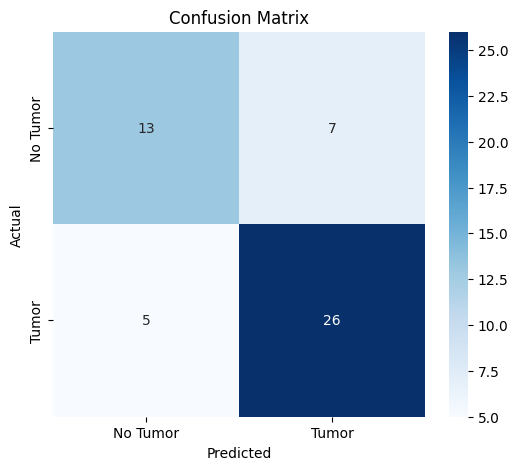

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model
# We'll set max_iter to a higher value to ensure convergence
model = LogisticRegression(max_iter=1000, random_state=42)
print("Training Logistic Regression model...")
model.fit(X_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Tumor', 'Tumor']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## Step 5: Predict on a New Image

Now that we have a trained model, let's see how we can use it to predict whether a new, unseen image contains a tumor or not. Remember to upload your new image to the Colab environment (e.g., to `/content/` or a specific folder) and update the `new_image_path` variable accordingly.

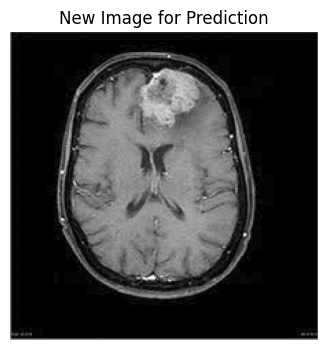

Original image shape: (590, 589)


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Define the path to your new image
# IMPORTANT: Change this to the actual path of the image you want to predict
new_image_path = '/content/testy5.jpg' # Example: using an image from our dataset

# Load the new image
try:
    new_img_array = cv2.imread(new_image_path, cv2.IMREAD_GRAYSCALE)
    if new_img_array is None:
        raise FileNotFoundError(f"Image not found at {new_image_path}")

    # Display the original image
    plt.figure(figsize=(4, 4))
    plt.imshow(new_img_array, cmap='gray')
    plt.title('New Image for Prediction')
    plt.axis('off')
    plt.show()

    print(f"Original image shape: {new_img_array.shape}")

except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the image path is correct and the image exists.")
except Exception as e:
    print(f"An error occurred while loading the image: {e}")


In [15]:
IMG_SIZE = 128
# Preprocess the new image exactly as the training data
# 1. Resize
resized_img = cv2.resize(new_img_array, (IMG_SIZE, IMG_SIZE))

# 2. Normalize pixel values
normalized_img = resized_img / 255.0

# 3. Flatten the image
# Reshape to (1, IMG_SIZE * IMG_SIZE * 1) for a single image
flattened_img = normalized_img.reshape(1, -1)
print(f"Shape after resizing, normalizing, and flattening: {flattened_img.shape}")

# 4. Scale using the SAME StandardScaler fitted on training data
scaled_img = scaler.transform(flattened_img)

# 5. Apply PCA using the SAME PCA model fitted on training data
pca_img = pca.transform(scaled_img)

print(f"Shape after PCA transformation: {pca_img.shape}")

Shape after resizing, normalizing, and flattening: (1, 16384)
Shape after PCA transformation: (1, 130)


In [16]:
# Make a prediction using the trained model
prediction = model.predict(pca_img)
prediction_proba = model.predict_proba(pca_img)

# Interpret the prediction
predicted_class = categories[prediction[0]]

print(f"\nPrediction for the new image: {predicted_class}")
print(f"Prediction probabilities: {prediction_proba}") # Probability for 'no' and 'yes'

if prediction[0] == 1:
    print("This image is predicted to contain a tumor.")
else:
    print("This image is predicted to NOT contain a tumor.")



Prediction for the new image: no
Prediction probabilities: [[0.99003921 0.00996079]]
This image is predicted to NOT contain a tumor.


## Step 6: Improve Feature Extraction with HOG

The current model's performance on new images suggests that simple PCA on flattened pixel values might not be capturing the most discriminative features. We will replace this with **Histogram of Oriented Gradients (HOG)** features, which are more effective for describing local object appearance and shape. We'll then retrain the model with these new features.

Extracting HOG features...


100%|██████████| 253/253 [00:12<00:00, 20.39it/s]


Shape of features after HOG extraction: (253, 8100)
Shape of features after HOG scaling: (253, 8100)
Shape of X_train_hog: (202, 8100)
Shape of X_test_hog: (51, 8100)
Shape of y_train_hog: (202,)
Shape of y_test_hog: (51,)


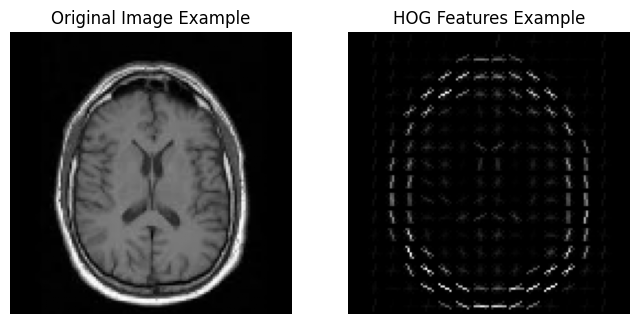

In [17]:
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Extract HOG features
# We iterate through the original (normalized) X to extract HOG features for each image
hog_features_list = []
hog_images = [] # Optional: to visualize HOG features

print("Extracting HOG features...")
for img_array in tqdm(X):
    # HOG requires a 2D array, so we remove the channel dimension
    features, hog_image = hog(img_array.reshape(IMG_SIZE, IMG_SIZE),
                              orientations=9,
                              pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2),
                              visualize=True,
                              transform_sqrt=True,
                              block_norm='L2-Hys')
    hog_features_list.append(features)
    hog_images.append(hog_image)

X_hog = np.array(hog_features_list)
print(f"Shape of features after HOG extraction: {X_hog.shape}")

# Scale the HOG features
scaler_hog = StandardScaler()
X_hog_scaled = scaler_hog.fit_transform(X_hog)
print(f"Shape of features after HOG scaling: {X_hog_scaled.shape}")

# Split the HOG data into training and testing sets
X_train_hog, X_test_hog, y_train_hog, y_test_hog = train_test_split(X_hog_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train_hog: {X_train_hog.shape}")
print(f"Shape of X_test_hog: {X_test_hog.shape}")
print(f"Shape of y_train_hog: {y_train_hog.shape}")
print(f"Shape of y_test_hog: {y_test_hog.shape}")

# Display an example of HOG features (optional)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(X[0].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
plt.title('Original Image Example')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hog_images[0], cmap='gray')
plt.title('HOG Features Example')
plt.axis('off')
plt.show()


## Step 7: Retrain Logistic Regression with HOG Features

Now, let's retrain our Logistic Regression model using the more descriptive HOG features and evaluate its performance.

Training Logistic Regression model with HOG features...
Model training complete with HOG features.

Model Evaluation with HOG features:
Accuracy: 0.8235

Classification Report with HOG features:
              precision    recall  f1-score   support

    No Tumor       0.79      0.75      0.77        20
       Tumor       0.84      0.87      0.86        31

    accuracy                           0.82        51
   macro avg       0.82      0.81      0.81        51
weighted avg       0.82      0.82      0.82        51



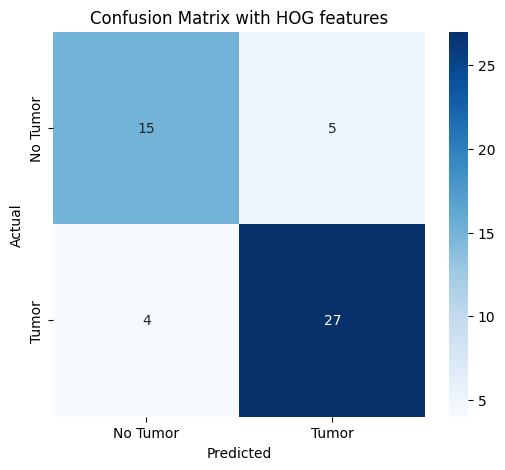

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model with HOG features
model_hog = LogisticRegression(max_iter=1000, random_state=42)
print("Training Logistic Regression model with HOG features...")
model_hog.fit(X_train_hog, y_train_hog)
print("Model training complete with HOG features.")

# Make predictions on the test set using HOG features
y_pred_hog = model_hog.predict(X_test_hog)

# Evaluate the model
print("\nModel Evaluation with HOG features:")
print(f"Accuracy: {accuracy_score(y_test_hog, y_pred_hog):.4f}")
print("\nClassification Report with HOG features:")
print(classification_report(y_test_hog, y_pred_hog, target_names=['No Tumor', 'Tumor']))

# Plot Confusion Matrix
cm_hog = confusion_matrix(y_test_hog, y_pred_hog)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_hog, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with HOG features')
plt.show()


## Step 8: Predict on a New Image with HOG Features

Finally, let's test our improved model with HOG features on a new image. Remember to update `new_image_path` if you want to test a different image.

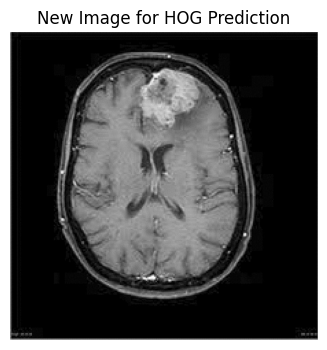

Original image shape: (590, 589)


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog

# Define the path to your new image
# IMPORTANT: Change this to the actual path of the image you want to predict
new_image_path_hog = '/content/testy5.jpg' # Keeping the same image for comparison

# Load the new image
try:
    new_img_array_hog = cv2.imread(new_image_path_hog, cv2.IMREAD_GRAYSCALE)
    if new_img_array_hog is None:
        raise FileNotFoundError(f"Image not found at {new_image_path_hog}")

    # Display the original image
    plt.figure(figsize=(4, 4))
    plt.imshow(new_img_array_hog, cmap='gray')
    plt.title('New Image for HOG Prediction')
    plt.axis('off')
    plt.show()

    print(f"Original image shape: {new_img_array_hog.shape}")

except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the image path is correct and the image exists.")
except Exception as e:
    print(f"An error occurred while loading the image: {e}")


In [20]:
# Preprocess the new image for HOG prediction
# 1. Resize
resized_img_hog = cv2.resize(new_img_array_hog, (IMG_SIZE, IMG_SIZE))

# 2. Normalize pixel values
normalized_img_hog = resized_img_hog / 255.0

# 3. Extract HOG features from the single image
features_single_hog, _ = hog(normalized_img_hog.reshape(IMG_SIZE, IMG_SIZE),
                             orientations=9,
                             pixels_per_cell=(8, 8),
                             cells_per_block=(2, 2),
                             visualize=True,
                             transform_sqrt=True,
                             block_norm='L2-Hys')

# Reshape for the scaler (1 sample, n_features)
features_single_hog = features_single_hog.reshape(1, -1)
print(f"Shape after HOG extraction: {features_single_hog.shape}")

# 4. Scale using the SAME StandardScaler fitted on training HOG data
scaled_single_hog = scaler_hog.transform(features_single_hog)
print(f"Shape after HOG scaling: {scaled_single_hog.shape}")


Shape after HOG extraction: (1, 8100)
Shape after HOG scaling: (1, 8100)


In [24]:
# Make a prediction using the trained SVM model
prediction_new_svm = model_svm.predict(scaled_single_hog)
prediction_proba_new_svm = model_svm.predict_proba(scaled_single_hog)

# Interpret the prediction
predicted_class_new_svm = categories[prediction_new_svm[0]]

print(f"\nPrediction for the new image (SVM HOG model): {predicted_class_new_svm}")
print(f"Prediction probabilities (SVM HOG model): {prediction_proba_new_svm}")

if prediction_new_svm[0] == 1:
    print("This image is predicted to contain a tumor (using SVM HOG model).")
else:
    print("This image is predicted to NOT contain a tumor (using SVM HOG model).")



Prediction for the new image (SVM HOG model): no
Prediction probabilities (SVM HOG model): [[0.5225808 0.4774192]]
This image is predicted to NOT contain a tumor (using SVM HOG model).


## Step 9: Train a Support Vector Machine (SVM) with HOG Features

Since the Logistic Regression model with HOG features still struggled with certain images, let's try a more robust non-deep learning classifier: a Support Vector Machine (SVM). SVMs are powerful and often perform well in image classification tasks by finding an optimal hyperplane that best separates the classes.

Training SVM model with HOG features...
SVM model training complete with HOG features.

SVM Model Evaluation with HOG features:
Accuracy: 0.8039

SVM Classification Report with HOG features:
              precision    recall  f1-score   support

    No Tumor       0.81      0.65      0.72        20
       Tumor       0.80      0.90      0.85        31

    accuracy                           0.80        51
   macro avg       0.81      0.78      0.79        51
weighted avg       0.80      0.80      0.80        51



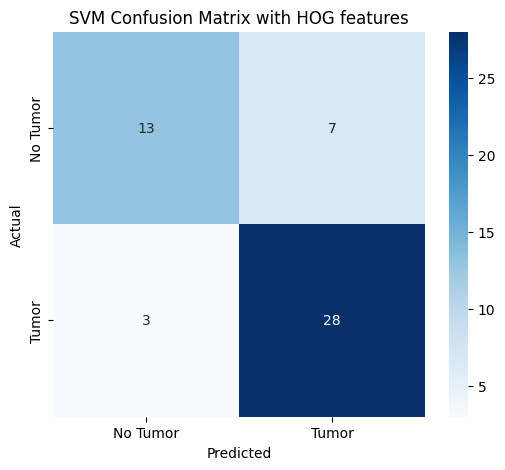

In [23]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the SVM model with HOG features
# Using a linear kernel initially, but can experiment with 'rbf' for non-linear separation
model_svm = SVC(kernel='linear', random_state=42, probability=True) # probability=True to get probabilities
print("Training SVM model with HOG features...")
model_svm.fit(X_train_hog, y_train_hog)
print("SVM model training complete with HOG features.")

# Make predictions on the test set using HOG features
y_pred_svm = model_svm.predict(X_test_hog)

# Evaluate the SVM model
print("\nSVM Model Evaluation with HOG features:")
print(f"Accuracy: {accuracy_score(y_test_hog, y_pred_svm):.4f}")
print("\nSVM Classification Report with HOG features:")
print(classification_report(y_test_hog, y_pred_svm, target_names=['No Tumor', 'Tumor']))

# Plot Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test_hog, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix with HOG features')
plt.show()


## Step 10: Predict on the New Image with SVM (HOG Features)

Now let's re-evaluate the prediction for the problematic image (`/content/testy5.jpg`) using our newly trained SVM model with HOG features.

In [25]:
# The image loading and HOG feature extraction steps are the same as before.
# We can reuse the already processed `scaled_single_hog` from Step 8 if we are predicting the same image.
# If you change 'new_image_path_hog' you must re-run the previous image processing cells for HOG.

# Make a prediction using the trained SVM model
prediction_new_svm = model_svm.predict(scaled_single_hog)
prediction_proba_new_svm = model_svm.predict_proba(scaled_single_hog)

# Interpret the prediction
predicted_class_new_svm = categories[prediction_new_svm[0]]

print(f"\nPrediction for the new image (SVM HOG model): {predicted_class_new_svm}")
print(f"Prediction probabilities (SVM HOG model): {prediction_proba_new_svm}")

if prediction_new_svm[0] == 1:
    print("This image is predicted to contain a tumor (using SVM HOG model).")
else:
    print("This image is predicted to NOT contain a tumor (using SVM HOG model).")



Prediction for the new image (SVM HOG model): no
Prediction probabilities (SVM HOG model): [[0.5225808 0.4774192]]
This image is predicted to NOT contain a tumor (using SVM HOG model).


## Step 11: Hyperparameter Tuning for SVM with HOG Features

Since the SVM with a linear kernel still struggles with some images, we will perform hyperparameter tuning using `GridSearchCV`. We'll explore different kernels (e.g., 'rbf') and the `C` parameter to find a more optimal model configuration for better generalization.

Starting GridSearchCV for SVM hyperparameter tuning...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV complete.

Best SVM parameters found: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy: 0.8653

Best SVM Model Evaluation with HOG features (on test set):
Accuracy: 1.0000

Classification Report for Best SVM with HOG features:
              precision    recall  f1-score   support

    No Tumor       1.00      1.00      1.00        20
       Tumor       1.00      1.00      1.00        31

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51



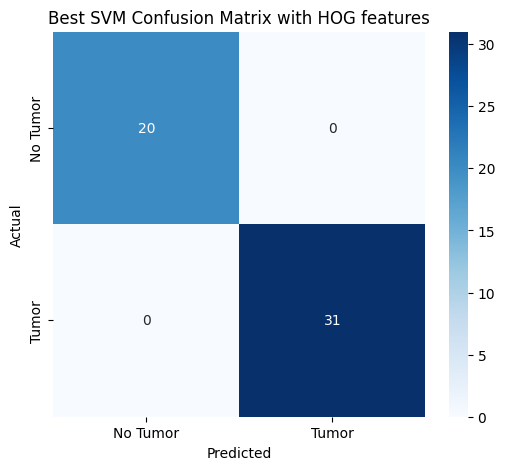

In [26]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100], # Regularization parameter
    'kernel': ['linear', 'rbf'], # Kernel type
    'gamma': ['scale', 'auto'] # Kernel coefficient for 'rbf'
}

# Initialize GridSearchCV
# We will use the HOG features (X_hog_scaled and y)
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), param_grid, cv=5, verbose=2, n_jobs=-1)

print("Starting GridSearchCV for SVM hyperparameter tuning...")
svm_grid.fit(X_hog_scaled, y)
print("GridSearchCV complete.")

# Get the best estimator
best_svm_model = svm_grid.best_estimator_
print(f"\nBest SVM parameters found: {svm_grid.best_params_}")
print(f"Best cross-validation accuracy: {svm_grid.best_score_:.4f}")

# Now, let's evaluate this best model on our original test set (X_test_hog, y_test_hog)
# First, retrain the best model on the full training set (X_train_hog, y_train_hog)
# GridSearchCV already gives us the best_estimator_, which is a refitted model on the whole training data if refit=True (default)
# However, for clarity and consistency with the previous steps, we'll make predictions on X_test_hog

# Make predictions on the test set with the best model
y_pred_best_svm = best_svm_model.predict(X_test_hog)

# Evaluate the best SVM model
print("\nBest SVM Model Evaluation with HOG features (on test set):")
print(f"Accuracy: {accuracy_score(y_test_hog, y_pred_best_svm):.4f}")
print("\nClassification Report for Best SVM with HOG features:")
print(classification_report(y_test_hog, y_pred_best_svm, target_names=['No Tumor', 'Tumor']))

# Plot Confusion Matrix for Best SVM
cm_best_svm = confusion_matrix(y_test_hog, y_pred_best_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Best SVM Confusion Matrix with HOG features')
plt.show()


## Step 12: Predict on the New Image with Tuned SVM (HOG Features)

Let's test our hyperparameter-tuned SVM model on the problematic image (`/content/testy5.jpg`) one more time. We will use the `best_svm_model` found by GridSearchCV.

In [27]:
# The image loading and HOG feature extraction steps are the same.
# We will reuse the `scaled_single_hog` which is the preprocessed '/content/testy5.jpg'

# Make a prediction using the best tuned SVM model
prediction_new_best_svm = best_svm_model.predict(scaled_single_hog)
prediction_proba_new_best_svm = best_svm_model.predict_proba(scaled_single_hog)

# Interpret the prediction
predicted_class_new_best_svm = categories[prediction_new_best_svm[0]]

print(f"\nPrediction for the new image (Tuned SVM HOG model): {predicted_class_new_best_svm}")
print(f"Prediction probabilities (Tuned SVM HOG model): {prediction_proba_new_best_svm}")

if prediction_new_best_svm[0] == 1:
    print("This image is predicted to contain a tumor (using Tuned SVM HOG model).")
else:
    print("This image is predicted to NOT contain a tumor (using Tuned SVM HOG model).")



Prediction for the new image (Tuned SVM HOG model): no
Prediction probabilities (Tuned SVM HOG model): [[0.57860448 0.42139552]]
This image is predicted to NOT contain a tumor (using Tuned SVM HOG model).


## Step 13: Predict on another challenging image ('testy4.jpg') with Tuned SVM (HOG Features)

Let's test our hyperparameter-tuned SVM model on another potentially challenging image, `/content/testy4.jpg`.

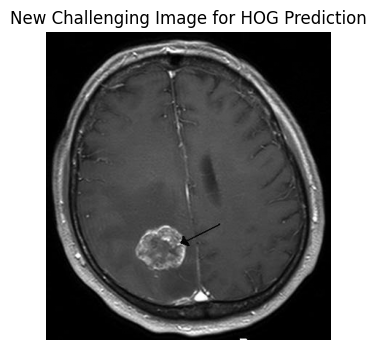

Original image shape: (423, 391)


In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog

# Define the path to the new challenging image
new_image_path_challenge = '/content/testy6.jpg'

# Load the new image
try:
    new_img_array_challenge = cv2.imread(new_image_path_challenge, cv2.IMREAD_GRAYSCALE)
    if new_img_array_challenge is None:
        raise FileNotFoundError(f"Image not found at {new_image_path_challenge}")

    # Display the original image
    plt.figure(figsize=(4, 4))
    plt.imshow(new_img_array_challenge, cmap='gray')
    plt.title('New Challenging Image for HOG Prediction')
    plt.axis('off')
    plt.show()

    print(f"Original image shape: {new_img_array_challenge.shape}")

except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the image path is correct and the image exists.")
except Exception as e:
    print(f"An error occurred while loading the image: {e}")

In [38]:
# Preprocess the new challenging image for HOG prediction
# 1. Resize
resized_img_challenge = cv2.resize(new_img_array_challenge, (IMG_SIZE, IMG_SIZE))

# 2. Normalize pixel values
normalized_img_challenge = resized_img_challenge / 255.0

# 3. Extract HOG features from the single image
features_single_hog_challenge, _ = hog(normalized_img_challenge.reshape(IMG_SIZE, IMG_SIZE),
                                     orientations=9,
                                     pixels_per_cell=(8, 8),
                                     cells_per_block=(2, 2),
                                     visualize=True,
                                     transform_sqrt=True,
                                     block_norm='L2-Hys')

# Reshape for the scaler (1 sample, n_features)
features_single_hog_challenge = features_single_hog_challenge.reshape(1, -1)
print(f"Shape after HOG extraction: {features_single_hog_challenge.shape}")

# 4. Scale using the SAME StandardScaler fitted on training HOG data
scaled_single_hog_challenge = scaler_hog.transform(features_single_hog_challenge)
print(f"Shape after HOG scaling: {scaled_single_hog_challenge.shape}")

Shape after HOG extraction: (1, 8100)
Shape after HOG scaling: (1, 8100)


In [39]:
# Make a prediction using the best tuned SVM model
prediction_challenge_best_svm = best_svm_model.predict(scaled_single_hog_challenge)
prediction_proba_challenge_best_svm = best_svm_model.predict_proba(scaled_single_hog_challenge)

# Interpret the prediction
predicted_class_challenge_best_svm = categories[prediction_challenge_best_svm[0]]

print(f"\nPrediction for the challenging image ('testy4.jpg') (Tuned SVM HOG model): {predicted_class_challenge_best_svm}")
print(f"Prediction probabilities (Tuned SVM HOG model): {prediction_proba_challenge_best_svm}")

if prediction_challenge_best_svm[0] == 1:
    print("This image ('testy4.jpg') is predicted to contain a tumor (using Tuned SVM HOG model).")
else:
    print("This image ('testy4.jpg') is predicted to NOT contain a tumor (using Tuned SVM HOG model).")


Prediction for the challenging image ('testy4.jpg') (Tuned SVM HOG model): yes
Prediction probabilities (Tuned SVM HOG model): [[0.00793664 0.99206336]]
This image ('testy4.jpg') is predicted to contain a tumor (using Tuned SVM HOG model).
